In [1]:
###########################################
####  轨迹质量控制 + 混合效应模型分析  ####
###########################################

# =============================================================================
# T细胞迁移分析：轨迹质量控制 + 混合效应模型
# 包含：
#   1. 轨迹质量评估和过滤
#   2. 样本匹配方案
#   3. 混合效应模型（考虑视频间变异）
#   4. 细胞级别绘图 + source data导出
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import zscore
import os
import glob
from datetime import datetime
import random
import warnings
warnings.filterwarnings('ignore')

# 混合效应模型
import statsmodels.api as sm
from statsmodels.formula.api import mixedlm
from statsmodels.stats.multitest import multipletests

# =============================================================================
# 配置
# =============================================================================
DATA_DIR = r"H:\ZQ_WLlab\movies\track_analysis_output_v4"
OUTPUT_DIR = r"H:\ZQ_WLlab\movies\track_analysis_output_v5_20260917\figures"
os.makedirs(OUTPUT_DIR, exist_ok=True)

PIXEL_SIZE_UM = 0.05416
FPS = 1.0 / 120.0
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")

# =============================================================================
# 匹配方案（Match Plan）
# =============================================================================

SAMPLE_MATCH_FILE = r"H:\ZQ_WLlab\movies\track_analysis_output_v4\figures\match_info_20260624_105543.csv"

SAMPLE_MATCH_PLAN = {
    'n_videos_per_group': 12,
    'ctrl_videos': [
        '2_1_Pos_Merge_405_Em450_488_Em525_561_Em609_2DSIM-3_cDC_CD4Tn_CD8Tn_1.avi',
        '6_3_Pos_Merge_405_Em450_488_Em525_561_Em609_2DSIM-3_cDC_CD4_CD8.avi',
        '8_Merge_405_Em450_488_Em525_561_Em609_2DSIM-3_cDC_CD4_CD8.avi',
        '6_4_Pos_Merge_405_Em450_488_Em525_561_Em609_2DSIM-3_cDC_CD4_CD8.avi',
        '2_14_Pos_Merge_405_Em450_488_Em525_561_Em609_2DSIM-3_cDC_CD4Tn_CD8Tn.avi',
        '2_Merge_405_Em450_488_Em525_561_Em609_2DSIM-3_cDC_CD4_CD8_1.avi',
        '37_Merge_405_Em450_488_Em525_561_Em609_2DSIM-3_1.avi',
        '2_4_Pos_Merge_405_Em450_488_Em525_561_Em609_2DSIM-3_cDC_CD4Tn_CD8Tn.avi',
        '6_4_Pos_Merge_405_Em450_488_Em525_561_Em609_2DSIM-3_1.avi',
        '6_3_Pos_Merge_405_Em450_488_Em525_561_Em609_2DSIM-3_1.avi',
        '5_Merge_405_Em450_488_Em525_561_Em609_2DSIM-3_1.avi',
        '30_Merge_405_Em450_488_Em525_561_Em609_2DSIM-3_1.avi',
    ],
    'ccri_videos': [
        '2_5_Pos_Merge_405_Em450_488_Em525_561_Em609_2DSIM-3_cDC_CD4T.avi',
        '21_Merge_405_Em450_488_Em525_561_Em609_2DSIM-3_1.avi',
        '22_Merge_405_Em450_488_Em525_561_Em609_2DSIM-3_1.avi',
        '17_Merge_405_Em450_488_Em525_561_Em609_2DSIM-3_1.avi',
        '40_Merge_405_Em450_488_Em525_561_Em609_2DSIM-3_1.avi',
        '18_Merge_405_Em450_488_Em525_561_Em609_2DSIM-3_1.avi',
        '2_16_Pos_Merge_405_Em450_488_Em525_561_Em609_2DSIM-3_cDC_CD4Tn_CD8Tn.avi',
        '6_0_Merge488-561__2DSIM-3_cDC_CD4_CD8.avi',
        '5_Merge_405_Em450_488_Em525_561_Em609_2DSIM-3_cDC_CD4_CD8.avi',
        '19_Merge_405_Em450_488_Em525_561_Em609_2DSIM-3_1.avi',
        '7_Merge_405_Em450_488_Em525_561_Em609_2DSIM-3_cDC_CD4_CD8.avi',
       # '6_Merge_405_Em450_488_Em525_561_Em609_2DSIM-3_cDC_CD4_CD8.avi',
    ],
}


# =============================================================================
# 分组映射
# =============================================================================
GROUP_MAPPING = {
    # Ctrl组
    '2_14_Pos_Merge_405_Em450_488_Em525_561_Em609_2DSIM-3_cDC_CD4Tn_CD8Tn': 'Ctrl',
    '2_1_Pos_Merge_405_Em450_488_Em525_561_Em609_2DSIM-3_cDC_CD4Tn_CD8Tn_1': 'Ctrl',
    '2_4_Pos_Merge_405_Em450_488_Em525_561_Em609_2DSIM-3_cDC_CD4Tn_CD8Tn': 'Ctrl',
    '2_Merge_405_Em450_488_Em525_561_Em609_2DSIM-3_cDC_CD4_CD8_1': 'Ctrl',
    '30_Merge_405_Em450_488_Em525_561_Em609_2DSIM-3_1': 'Ctrl',
    '37_Merge_405_Em450_488_Em525_561_Em609_2DSIM-3_1': 'Ctrl',
    '5_Merge_405_Em450_488_Em525_561_Em609_2DSIM-3_1': 'Ctrl',
    '6_3_Pos_Merge_405_Em450_488_Em525_561_Em609_2DSIM-3_1': 'Ctrl',
    '6_3_Pos_Merge_405_Em450_488_Em525_561_Em609_2DSIM-3_cDC_CD4_CD8': 'Ctrl',
    '6_4_Pos_Merge_405_Em450_488_Em525_561_Em609_2DSIM-3_1': 'Ctrl',
    '6_4_Pos_Merge_405_Em450_488_Em525_561_Em609_2DSIM-3_cDC_CD4_CD8': 'Ctrl',
    '8_Merge_405_Em450_488_Em525_561_Em609_2DSIM-3_cDC_CD4_CD8': 'Ctrl',

    # CCR7i组
    '19_Merge_405_Em450_488_Em525_561_Em609_2DSIM-3_1': 'CCR7i',
    '18_Merge_405_Em450_488_Em525_561_Em609_2DSIM-3_1': 'CCR7i',
    '17_Merge_405_Em450_488_Em525_561_Em609_2DSIM-3_1': 'CCR7i',
    '21_Merge_405_Em450_488_Em525_561_Em609_2DSIM-3_1': 'CCR7i',
    '22_Merge_405_Em450_488_Em525_561_Em609_2DSIM-3_1': 'CCR7i',
    '2_16_Pos_Merge_405_Em450_488_Em525_561_Em609_2DSIM-3_cDC_CD4Tn_CD8Tn': 'CCR7i',
    '2_5_Pos_Merge_405_Em450_488_Em525_561_Em609_2DSIM-3_cDC_CD4T': 'CCR7i',
    '40_Merge_405_Em450_488_Em525_561_Em609_2DSIM-3_1': 'CCR7i',
    '5_Merge_405_Em450_488_Em525_561_Em609_2DSIM-3_cDC_CD4_CD8': 'CCR7i',
    '6_0_Merge488-561__2DSIM-3_cDC_CD4_CD8': 'CCR7i',
    '6_Merge_405_Em450_488_Em525_561_Em609_2DSIM-3_cDC_CD4_CD8': 'CCR7i',
    '7_Merge_405_Em450_488_Em525_561_Em609_2DSIM-3_cDC_CD4_CD8': 'CCR7i',
}



In [2]:
# =============================================================================
# 第1部分：轨迹质量控制
# =============================================================================

def load_frame_data():
    """加载逐帧数据"""
    frame_files = sorted(glob.glob(os.path.join(DATA_DIR, "all_videos_frame_level_*.csv")))
    if not frame_files:
        raise FileNotFoundError("未找到逐帧数据文件！")

    print(f"加载逐帧数据: {os.path.basename(frame_files[-1])}")
    df_frame = pd.read_csv(frame_files[-1])

    def assign_group(video_name):
        key = os.path.splitext(video_name)[0]
        return GROUP_MAPPING.get(key, 'Unknown')

    df_frame['group'] = df_frame['video_name'].apply(assign_group)
    df_frame = df_frame[df_frame['group'].isin(['Ctrl', 'CCR7i'])]

    return df_frame

def evaluate_track_quality(df_frame):
    """
    评估每条轨迹的质量

    质量指标：
    1. 帧间跳跃距离（过大说明可能连错了细胞）
    2. 轨迹断点（gap过多说明追踪不稳定）
    3. 轨迹长度（过短说明信号弱）
    4. 速度突变（瞬时速度过大）
    5. 方向一致性（频繁反向可能有问题）
    """
    print(f"\n{'='*70}")
    print("轨迹质量控制")
    print(f"{'='*70}")

    quality_scores = []

    for (video_name, cell_type, particle), track in df_frame.groupby(['video_name', 'cell_type', 'particle']):
        track = track.sort_values('frame')

        if len(track) < 3:
            continue

        # 1. 帧间位移统计
        displacements = np.sqrt(track['dx_um'].diff().dropna()**2 + track['dy_um'].diff().dropna()**2)
        max_displacement = displacements.max() if len(displacements) > 0 else 0
        mean_displacement = displacements.mean() if len(displacements) > 0 else 0
        std_displacement = displacements.std() if len(displacements) > 0 else 0

        # 2. 轨迹长度
        track_length = len(track)

        # 3. 帧间隔（检测gap）
        frame_diffs = np.diff(track['frame'].values)
        max_gap = frame_diffs.max() if len(frame_diffs) > 0 else 1
        n_gaps = np.sum(frame_diffs > 1)
        gap_ratio = n_gaps / track_length if track_length > 0 else 0

        # 4. 速度统计
        speeds = track['instant_speed_um_per_s'].dropna()
        max_speed = speeds.max() if len(speeds) > 0 else 0
        cv_speed = speeds.std() / speeds.mean() if speeds.mean() > 0 else 0  # 变异系数

        # 5. 方向变化（角度变化的标准差）
        if len(track) >= 3:
            angles = np.arctan2(track['dy_um'].diff(), track['dx_um'].diff()).dropna()
            angle_changes = np.abs(np.diff(angles))
            angle_changes = np.minimum(angle_changes, 2*np.pi - angle_changes)  # 处理圆周
            mean_angle_change = angle_changes.mean() if len(angle_changes) > 0 else 0
        else:
            mean_angle_change = 0

        # 6. 趋近/远离一致性
        v_towards = track['v_towards_cDC_um_s'].dropna()
        if len(v_towards) > 0:
            approach_consistency = np.sum(v_towards > 0) / len(v_towards)  # 趋近比例
        else:
            approach_consistency = 0.5

        quality_scores.append({
            'video_name': video_name,
            'cell_type': cell_type,
            'particle': particle,
            'track_length': track_length,
            'max_displacement_um': max_displacement,
            'mean_displacement_um': mean_displacement,
            'std_displacement_um': std_displacement,
            'max_gap': max_gap,
            'n_gaps': n_gaps,
            'gap_ratio': gap_ratio,
            'max_speed': max_speed,
            'cv_speed': cv_speed,
            'mean_angle_change': mean_angle_change,
            'approach_consistency': approach_consistency,
            'n_frames_total': track['frame'].nunique(),
        })

    df_quality = pd.DataFrame(quality_scores)

    print(f"总轨迹数: {len(df_quality)}")

    # 计算质量得分（加权综合）
    # 正常化各指标
    for col in ['max_displacement_um', 'max_gap', 'gap_ratio', 'max_speed', 'cv_speed']:
        if col in df_quality.columns and len(df_quality) > 0:
            df_quality[f'{col}_zscore'] = np.abs(zscore(df_quality[col].fillna(0)))

    # 综合质量得分（越低越好）
    df_quality['quality_score'] = (
        df_quality['max_displacement_um_zscore'].fillna(0) * 2.0 +  # 跳跃距离权重高
        df_quality['max_gap_zscore'].fillna(0) * 2.0 +              # Gap权重高
        df_quality['gap_ratio_zscore'].fillna(0) * 1.5 +
        df_quality['max_speed_zscore'].fillna(0) * 1.5 +
        df_quality['cv_speed_zscore'].fillna(0) * 1.0
    )

    return df_quality

def filter_tracks_by_quality(df_frame, df_quality,
                              max_displacement_threshold=30,  # μm, 单帧最大跳跃
                              max_gap_threshold=3,            # 最大帧间隔
                              min_track_length=3,              # 最小轨迹长度
                              quality_percentile=90):          # 质量得分阈值
    """
    根据质量指标过滤轨迹

    排除标准（在Methods中报告）：
    1. 单帧位移 > 30 μm（细胞不可能瞬间移动这么远）
    2. 最大帧间隔 > 3帧（追踪断点过长）
    3. 轨迹长度 < 3帧
    4. 综合质量得分 > 90%分位数
    """
    print(f"\n{'='*70}")
    print("轨迹过滤")
    print(f"{'='*70}")

    n_before = df_quality['particle'].nunique()

    # 1. 排除跳跃过大的轨迹
    bad_jump = df_quality['max_displacement_um'] > max_displacement_threshold
    n_bad_jump = bad_jump.sum()

    # 2. 排除gap过大的轨迹
    bad_gap = df_quality['max_gap'] > max_gap_threshold
    n_bad_gap = bad_gap.sum()

    # 3. 排除过短的轨迹
    too_short = df_quality['track_length'] < min_track_length
    n_too_short = too_short.sum()

    # 4. 排除质量差得分过高的（前10%）
    quality_threshold = np.percentile(df_quality['quality_score'].dropna(), quality_percentile)
    bad_quality = df_quality['quality_score'] > quality_threshold
    n_bad_quality = bad_quality.sum()

    # 综合过滤
    bad_mask = bad_jump | bad_gap | too_short | bad_quality
    good_tracks = df_quality[~bad_mask]

    n_after = good_tracks['particle'].nunique()

    print(f"过滤前轨迹数: {n_before}")
    print(f"排除原因:")
    print(f"  跳跃过大 (> {max_displacement_threshold} μm): {n_bad_jump}")
    print(f"  Gap过大 (> {max_gap_threshold} 帧): {n_bad_gap}")
    print(f"  轨迹过短 (< {min_track_length} 帧): {n_too_short}")
    print(f"  质量差得分过高 (> {quality_percentile}%): {n_bad_quality}")
    print(f"过滤后轨迹数: {n_after}")
    print(f"保留比例: {n_after/n_before*100:.1f}%")

    # 过滤逐帧数据
    good_particles = set(zip(good_tracks['video_name'], good_tracks['cell_type'], good_tracks['particle']))

    df_frame_filtered = df_frame[
        df_frame.apply(lambda row: (row['video_name'], row['cell_type'], row['particle']) in good_particles, axis=1)
    ].copy()

    # 按视频统计过滤情况
    video_stats = df_frame_filtered.groupby(['video_name', 'group']).agg(
        n_tracks=('particle', 'nunique'),
        n_frames=('frame', 'count'),
    ).reset_index()

    return df_frame_filtered, good_tracks, video_stats

def plot_quality_control_summary(df_quality, save_dir):
    """可视化质量控制结果"""
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))

    # 1. 轨迹长度分布
    ax = axes[0, 0]
    ax.hist(df_quality['track_length'], bins=50, color='steelblue', edgecolor='white', alpha=0.7)
    ax.axvline(df_quality['track_length'].median(), color='red', linestyle='--', label=f'Median={df_quality["track_length"].median():.0f}')
    ax.set_xlabel('Track Length (frames)')
    ax.set_ylabel('Count')
    ax.set_title('Track Length Distribution')
    ax.legend()

    # 2. 最大位移分布
    ax = axes[0, 1]
    ax.hist(df_quality['max_displacement_um'].clip(upper=100), bins=50, color='coral', edgecolor='white', alpha=0.7)
    ax.axvline(50, color='red', linestyle='--', label='Threshold=50 μm')
    ax.set_xlabel('Max Frame-to-Frame Displacement (μm)')
    ax.set_ylabel('Count')
    ax.set_title('Max Displacement Distribution')
    ax.legend()

    # 3. Gap比例分布
    ax = axes[0, 2]
    ax.hist(df_quality['gap_ratio'], bins=50, color='seagreen', edgecolor='white', alpha=0.7)
    ax.set_xlabel('Gap Ratio')
    ax.set_ylabel('Count')
    ax.set_title('Gap Ratio Distribution')

    # 4. 最大速度分布
    ax = axes[1, 0]
    ax.hist(df_quality['max_speed'].clip(upper=0.1), bins=50, color='purple', edgecolor='white', alpha=0.7)
    ax.set_xlabel('Max Speed (μm/min)')
    ax.set_ylabel('Count')
    ax.set_title('Max Speed Distribution')

    # 5. 质量得分分布
    ax = axes[1, 1]
    ax.hist(df_quality['quality_score'].dropna(), bins=50, color='goldenrod', edgecolor='white', alpha=0.7)
    ax.axvline(np.percentile(df_quality['quality_score'].dropna(), 90), color='red', linestyle='--', label='90th percentile')
    ax.set_xlabel('Quality Score')
    ax.set_ylabel('Count')
    ax.set_title('Quality Score Distribution')
    ax.legend()

    # 6. 每组过滤前后对比
    ax = axes[1, 2]
    group_counts = df_quality.groupby(['video_name']).size().reset_index(name='n_tracks')
    group_counts['group'] = group_counts['video_name'].apply(
        lambda x: GROUP_MAPPING.get(os.path.splitext(x)[0], 'Unknown')
    )

    for grp, color in [('Ctrl', '#4DBBD5'), ('CCR7i', '#E64B35')]:
        data = group_counts[group_counts['group'] == grp]['n_tracks']
        ax.hist(data, bins=20, alpha=0.5, color=color, label=f'{grp} (n={len(data)} videos)')

    ax.set_xlabel('Number of Tracks per Video')
    ax.set_ylabel('Count')
    ax.set_title('Tracks per Video by Group')
    ax.legend()

    plt.suptitle('Trajectory Quality Control Summary', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'quality_control_summary.png'), dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()

    return fig


In [3]:
# =============================================================================
# 第2部分：数据准备
# =============================================================================

def calculate_video_level_metrics(df_frame):
    """计算视频级别的趋近速度"""
    df_approach = df_frame[df_frame['v_towards_cDC_um_s'] > 0].copy()
    print(f"趋近时刻: {len(df_approach)} 行 ({len(df_approach)/len(df_frame)*100:.1f}%)")

    video_stats = df_approach.groupby(['video_name']).agg(
        n_cells=('particle', 'nunique'),
        n_approach_events=('v_towards_cDC_um_s', 'count'),
        mean_v_approach=('v_towards_cDC_um_s', 'mean'),
        median_v_approach=('v_towards_cDC_um_s', 'median'),
    ).reset_index()

    video_stats['video_key'] = video_stats['video_name'].apply(lambda x: os.path.splitext(x)[0])
    video_stats['group'] = video_stats['video_key'].map(GROUP_MAPPING)

    return video_stats

def get_cell_metrics_for_videos(df_frame, video_names):
    """获取指定视频列表的细胞级别指标"""
    df_matched = df_frame[
        (df_frame['video_name'].isin(video_names)) &
        (df_frame['v_towards_cDC_um_s'] > 0)
    ].copy()

    cell_metrics = df_matched.groupby(['video_name', 'group', 'cell_type', 'particle']).agg(
        mean_v_approach=('v_towards_cDC_um_s', 'mean'),
        median_v_approach=('v_towards_cDC_um_s', 'median'),
        max_v_approach=('v_towards_cDC_um_s', 'max'),
        sem_v_approach=('v_towards_cDC_um_s', 'sem'),
        mean_speed_approach=('instant_speed_um_per_s', 'mean'),
        max_speed_approach=('instant_speed_um_per_s', 'max'),
        mean_CI_approach=('chemotaxis_index', 'mean'),
        median_CI_approach=('chemotaxis_index', 'median'),
        mean_dist_to_cDC=('dist_to_cDC_um', 'mean'),
        min_dist_to_cDC=('dist_to_cDC_um', 'min'),
        n_approach_events=('frame', 'count'),
    ).reset_index()

    cell_metrics = cell_metrics[cell_metrics['n_approach_events'] >= 3]

    # 在return之前转换为 μm/min
    cell_metrics['mean_v_approach_um_per_min'] = cell_metrics['mean_v_approach'] * 60
    cell_metrics['median_v_approach_um_per_min'] = cell_metrics['median_v_approach'] * 60
    cell_metrics['max_v_approach_um_per_min'] = cell_metrics['max_v_approach'] * 60
    cell_metrics['mean_speed_approach_um_per_min'] = cell_metrics['mean_speed_approach'] * 60

    return cell_metrics

In [7]:
# =============================================================================
# 第3部分：匹配方案的校验
# =============================================================================

def verify_sample_match_plan(best_match, df_frame_filtered):
    """
    校验方案中的视频是否都在 QC 过滤后的数据集中。
    """
    available = set(df_frame_filtered['video_name'].unique())
    missing_ctrl = [v for v in best_match['ctrl_videos'] if v not in available]
    missing_ccri = [v for v in best_match['ccri_videos'] if v not in available]
    if missing_ctrl or missing_ccri:
        raise ValueError(
            f"方案中的视频在QC过滤后数据集中缺失：\n"
            f"  Ctrl 缺失: {missing_ctrl}\n"
            f"  CCR7i 缺失: {missing_ccri}\n"
            f"检查 GROUP_MAPPING 的 key 是否与 video_name（去扩展名后）完全一致。"
        )
    print(f"方案校验通过：Ctrl {len(best_match['ctrl_videos'])} 视频, "
          f"CCR7i {len(best_match['ccri_videos'])} 视频 均在数据集中")

In [9]:
# =============================================================================
# 混合效应模型（设定Ctrl为reference）
# =============================================================================

def run_mixed_effects_model_fixed(cell_metrics, save_dir):
    """
    明确将Ctrl设为reference level
    模型公式: mean_v_approach ~ C(group, Treatment('Ctrl')) + (1|video_name)

     返回字典统一使用以下key：
        intercept, group_effect, p_value, var_residual, var_random_intercept,
        icc, n_videos, n_cells, ctrl_mean, ccri_mean
    """
    print(f"\n{'='*70}")
    print("混合效应模型分析（Ctrl为reference）")
    print(f"{'='*70}")

    results = {}

    for cell_type in ['CD4_Tn', 'CD8_Tn']:
        print(f"\n--- {cell_type} ---")

        subset = cell_metrics[cell_metrics['cell_type'] == cell_type].copy()
        subset = subset.dropna(subset=['mean_v_approach'])

        # 明确设定Ctrl为reference
        subset['group'] = pd.Categorical(subset['group'], categories=['Ctrl', 'CCR7i'], ordered=True)

        print(f"总细胞数: {len(subset)}")
        print(f"视频数: {subset['video_name'].nunique()}")

        # 各组基础统计（仅打印均值，避免引用未定义变量）
        for grp in ['Ctrl', 'CCR7i']:
            grp_data = subset[subset['group'] == grp]
            if len(grp_data) > 0:
                print(f"  {grp} 组均值: {grp_data['mean_v_approach'].mean():.6f} μm/min (n={len(grp_data)} cells)")
            else:
                print(f"  {grp}: 无数据")

        try:
            # 混合效应模型（Ctrl作为reference）
            model = mixedlm(
                "mean_v_approach ~ C(group, Treatment('Ctrl'))",
                data=subset,
                groups=subset["video_name"],
                re_formula="~1"
            )
            fit = model.fit(reml=True)

            print(f"\n模型拟合结果:")
            print(fit.summary())

            # 提取关键参数
            intercept = fit.fe_params.get('Intercept', np.nan)

            # 找到CCR7i的效应
            ccri_param_name = [c for c in fit.fe_params.index if 'CCR7i' in c]
            if ccri_param_name:
                ccri_effect = fit.fe_params[ccri_param_name[0]]
                ccri_pval = fit.pvalues[ccri_param_name[0]]
            else:
                ccri_effect = np.nan
                ccri_pval = np.nan

            # 方差分解
            var_residual = fit.scale
            try:
                var_random = fit.cov_re.values[0, 0]
            except:
                var_random = 0
            var_total = var_residual + var_random
            icc = var_random / var_total if var_total > 0 else 0

            # 统一key命名（匹配绘图函数的访问）
            results[cell_type] = {
                'intercept': intercept,
                'group_effect': ccri_effect,
                'p_value': ccri_pval,
                'var_residual': var_residual,
                'var_random_intercept': var_random,
                'icc': icc,
                'n_videos': subset['video_name'].nunique(),
                'n_cells': len(subset),
                'ctrl_mean': subset[subset['group']=='Ctrl']['mean_v_approach'].mean(),
                'ccri_mean': subset[subset['group']=='CCR7i']['mean_v_approach'].mean(),
            }

            print(f"\n{'='*50}")
            print(f"关键结果解释:")
            print(f"{'='*50}")
            print(f"  Intercept (Ctrl组均值): {intercept:.6f} μm/min")
            print(f"  CCR7i效应 (CCR7i - Ctrl): {ccri_effect:.6f} μm/min")
            print(f"    负值 = CCR7i降低趋近速度 ✓")
            print(f"    p-value: {ccri_pval:.4f}")
            print(f"  ICC (视频间变异占比): {icc:.4f} ({icc*100:.1f}%)")

            if ccri_effect < 0:
                print(f"\n  ✓ CCR7i组趋近速度低于Ctrl组")
                if ccri_pval < 0.05:
                    print(f"  ✓ 差异显著 (p={ccri_pval:.4f})")
                elif ccri_pval < 0.1:
                    print(f"  △ 边缘显著 (p={ccri_pval:.4f})")
                else:
                    print(f"  ✗ 不显著 (p={ccri_pval:.4f})")

        except Exception as e:
            print(f"模型拟合失败: {e}")
            import traceback
            traceback.print_exc()

            # 返回基本统计量
            results[cell_type] = {
                'intercept': np.nan,
                'group_effect': np.nan,
                'p_value': np.nan,
                'var_residual': np.nan,
                'var_random_intercept': np.nan,
                'icc': np.nan,
                'n_videos': subset['video_name'].nunique(),
                'n_cells': len(subset),
                'ctrl_mean': subset[subset['group']=='Ctrl']['mean_v_approach'].mean() if len(subset[subset['group']=='Ctrl'])>0 else np.nan,
                'ccri_mean': subset[subset['group']=='CCR7i']['mean_v_approach'].mean() if len(subset[subset['group']=='CCR7i'])>0 else np.nan,
            }

    # 保存结果
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    df_results = pd.DataFrame(results).T
    df_results.to_csv(os.path.join(save_dir, f'mixed_effects_results_{timestamp}.csv'), index=False)

    return results


def plot_mixed_effects_results(cell_metrics, mixed_results, save_dir):
    """可视化混合效应模型结果"""
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    colors = {'Ctrl':'#E64B35' , 'CCR7i': '#4DBBD5'}

    for idx, cell_type in enumerate(['CD4_Tn', 'CD8_Tn']):
        # 图1：按视频分组的散点图（显示视频间变异）
        ax = axes[idx, 0]
        subset = cell_metrics[cell_metrics['cell_type'] == cell_type].copy()

        # 计算每个视频的均值
        video_means = subset.groupby(['video_name', 'group'])['mean_v_approach'].mean().reset_index()
        video_means = video_means.sort_values('group')

        x_positions = []
        y_values = []
        color_list = []

        current_x = 0
        for grp in ['Ctrl', 'CCR7i']:
            grp_data = video_means[video_means['group'] == grp]
            for _, row in grp_data.iterrows():
                x_positions.append(current_x)
                y_values.append(row['mean_v_approach'])
                color_list.append(colors[grp])
                current_x += 1
            current_x += 1  # 组间间隔

        ax.bar(range(len(x_positions)), y_values, color=color_list, alpha=0.7)

        # 添加组均值线
        ctrl_mean = subset[subset['group']=='Ctrl']['mean_v_approach'].mean()
        ccri_mean = subset[subset['group']=='CCR7i']['mean_v_approach'].mean()

        n_ctrl = video_means[video_means['group']=='Ctrl'].shape[0]
        n_ccri = video_means[video_means['group']=='CCR7i'].shape[0]

        ax.axhline(ctrl_mean, color=colors['Ctrl'], linestyle='--', linewidth=2,
                  xmin=0, xmax=n_ctrl/(len(x_positions)), label=f'Ctrl mean={ctrl_mean:.4f}')
        ax.axhline(ccri_mean, color=colors['CCR7i'], linestyle='--', linewidth=2,
                  xmin=(n_ctrl+1)/len(x_positions), xmax=1, label=f'CCR7i mean={ccri_mean:.4f}')

        ax.set_ylabel('Mean V towards cDC (μm/min)')
        ax.set_title(f'{cell_type}: Video-Level Means')
        ax.legend(fontsize=8)

        # 图2：混合效应模型结果
        ax = axes[idx, 1]
        if cell_type in mixed_results:
            res = mixed_results[cell_type]

            # 显示结果文本
            textstr = (
                f"Mixed Effects Model Results:\n"
                f"{'='*40}\n"
                f"Fixed Effects:\n"
                f"  Intercept (Ctrl): {res['intercept']:.6f}\n"
                f"  Group (CCR7i): {res['group_effect']:.6f}\n"
                f"  p-value: {res['p_value']:.4f}\n"
                f"\n"
                f"Random Effects:\n"
                f"  σ²_residual: {res['var_residual']:.6f}\n"
                f"  σ²_video: {res['var_random_intercept']:.6f}\n"
                f"  ICC: {res['icc']:.4f}\n"
                f"\n"
                f"Sample Size:\n"
                f"  Videos: {res['n_videos']}\n"
                f"  Cells: {res['n_cells']}\n"
                f"\n"
                f"Group Means:\n"
                f"  Ctrl: {res['ctrl_mean']:.6f}\n"
                f"  CCR7i: {res['ccri_mean']:.6f}"
            )

            if not np.isnan(res['p_value']) and res['p_value'] < 0.05:
                textstr += "\n\n✓ Significant difference (p<0.05)"
            else:
                textstr += "\n\n✗ Not significant"

        ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=9,
               verticalalignment='top', fontfamily='monospace',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        ax.axis('off')
        ax.set_title(f'{cell_type}: Mixed Effects Model')

    plt.suptitle('Mixed Effects Model Analysis: Ctrl vs CCR7i', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'mixed_effects_analysis.png'), dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()

In [11]:
# =============================================================================
# 第5部分：绘图函数
# =============================================================================

def plot_cell_level_violin(cell_metrics, best_match, mixed_results, save_dir):
    """细胞级别小提琴图"""
    metrics_config = [
        ('mean_v_approach_um_per_min', 'Mean V towards cDC (μm/min)'),
        ('mean_CI_approach', 'Mean Chemotaxis Index'),
        ('mean_speed_approach_um_per_min', 'Mean Speed (μm/min)'),
    ]

    colors = {'Ctrl': '#E64B35', 'CCR7i': '#4DBBD5'}

    for cell_type in ['CD4_Tn', 'CD8_Tn']:
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))

        for idx, (metric, label) in enumerate(metrics_config):
            ax = axes[idx]

            subset = cell_metrics[
                (cell_metrics['cell_type'] == cell_type) &
                (cell_metrics['group'].isin(['Ctrl', 'CCR7i']))
            ].dropna(subset=[metric])

            if len(subset) == 0:
                ax.text(0.5, 0.5, 'No Data', ha='center', transform=ax.transAxes)
                continue

            ctrl = subset[subset['group'] == 'Ctrl'][metric]
            ccr7i = subset[subset['group'] == 'CCR7i'][metric]

            # 使用混合效应模型的p值
            if cell_type in mixed_results and not np.isnan(mixed_results[cell_type]['p_value']):
                pval = mixed_results[cell_type]['p_value']
            else:
                _, pval = stats.mannwhitneyu(ctrl, ccr7i, alternative='two-sided')

            if pval < 0.001:
                sig = '***'
            elif pval < 0.01:
                sig = '**'
            elif pval < 0.05:
                sig = '*'
            else:
                sig = f'p={pval:.3f}'

            d = (ctrl.mean() - ccr7i.mean()) / np.sqrt((ctrl.std()**2 + ccr7i.std()**2) / 2)

            # 小提琴图
            positions = [0, 1]
            vp = ax.violinplot([ctrl.values, ccr7i.values], positions=positions,
                              showmeans=False, showmedians=False,
                              showextrema=False, widths=0.7)
            for i, body in enumerate(vp['bodies']):
                body.set_facecolor(colors[['Ctrl', 'CCR7i'][i]])
                body.set_alpha(0.3)
                body.set_edgecolor('black')
                body.set_linewidth(0.5)

            # 箱线图
            ax.boxplot([ctrl.values, ccr7i.values], positions=positions,
                      widths=0.2, patch_artist=True, showfliers=False,
                      boxprops=dict(facecolor='white', alpha=0.8, linewidth=1.5),
                      medianprops=dict(color='black', linewidth=2),
                      whiskerprops=dict(linewidth=1), capprops=dict(linewidth=1))

            # 散点
            for i, data in enumerate([ctrl.values, ccr7i.values]):
                jitter = np.random.normal(0, 0.04, size=len(data))
                ax.scatter(np.full(len(data), i) + jitter, data,
                          alpha=0.3, s=8,
                          color=colors[['Ctrl', 'CCR7i'][i]],
                          edgecolors='none', zorder=3)

            # 均值线
            for i, data in enumerate([ctrl.values, ccr7i.values]):
                mean_val = np.mean(data)
                ax.plot([i-0.15, i+0.15], [mean_val, mean_val],
                       color='darkred', linewidth=2.5, zorder=5)

            # 显著性
            if pval < 0.1:
                y_max = max(ctrl.max(), ccr7i.max())
                y_range = y_max - min(ctrl.min(), ccr7i.min())
                ax.plot([0, 0, 1, 1],
                       [y_max+y_range*0.05, y_max+y_range*0.1,
                        y_max+y_range*0.1, y_max+y_range*0.05], 'k-', lw=1)
                ax.text(0.5, y_max+y_range*0.13, sig, ha='center',
                       fontsize=14, fontweight='bold')

            ax.text(0.98, 0.02, f'd={d:.3f}', transform=ax.transAxes,
                   fontsize=8, ha='right', va='bottom',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

            ax.set_xticks([0, 1])
            ax.set_xticklabels([f'Ctrl\n(n={len(ctrl)})',
                               f'CCR7i\n(n={len(ccr7i)})'], fontsize=10)
            ax.set_ylabel(label, fontsize=11)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)

            if 'V towards' in metric or 'Speed' in metric:
                ax.set_ylim(bottom=0)

        # 获取混合效应模型p值用于标题
        if cell_type in mixed_results:
            me_pval = mixed_results[cell_type]['p_value']
            me_text = f"Mixed Effects p={me_pval:.4f}" if not np.isnan(me_pval) else ""
        else:
            me_text = ""

        plt.suptitle(f'{cell_type}: Ctrl vs CCR7i\n({best_match["n_videos_per_group"]} videos/group, {me_text})',
                    fontsize=14, fontweight='bold', y=1.05)
        plt.tight_layout()
        filename = f'{cell_type}_violin_matched_qc.png'
        plt.savefig(os.path.join(save_dir, filename), dpi=300, bbox_inches='tight', facecolor='white')
        print(f"保存: {filename}")
        plt.show()

    return fig

def plot_combined_figure(cell_metrics, best_match, mixed_results, save_dir):
    """4合1组合图"""
    fig, axes = plt.subplots(2, 2, figsize=(12, 11))
    colors = {'Ctrl': '#E64B35', 'CCR7i': '#4DBBD5'}

    configs = [
        (0, 0, 'CD4_Tn', 'mean_v_approach_um_per_min', 'Mean V towards cDC (μm/min)'),
        (0, 1, 'CD8_Tn', 'mean_v_approach_um_per_min', 'Mean V towards cDC (μm/min)'),
        (1, 0, 'CD4_Tn', 'mean_CI_approach', 'Mean Chemotaxis Index'),
        (1, 1, 'CD8_Tn', 'mean_CI_approach', 'Mean Chemotaxis Index'),
    ]

    for row, col, ct, metric, label in configs:
        ax = axes[row, col]
        subset = cell_metrics[
            (cell_metrics['cell_type'] == ct) &
            (cell_metrics['group'].isin(['Ctrl', 'CCR7i']))
        ].dropna(subset=[metric])

        if len(subset) == 0:
            ax.text(0.5, 0.5, 'No Data', ha='center', transform=ax.transAxes)
            continue

        ctrl = subset[subset['group'] == 'Ctrl'][metric]
        ccr7i = subset[subset['group'] == 'CCR7i'][metric]

        if ct in mixed_results and not np.isnan(mixed_results[ct]['p_value']):
            pval = mixed_results[ct]['p_value']
        else:
            _, pval = stats.mannwhitneyu(ctrl, ccr7i, alternative='two-sided')

        sig = '***' if pval<0.001 else '**' if pval<0.01 else '*' if pval<0.05 else f'p={pval:.3f}'
        d = (ctrl.mean() - ccr7i.mean()) / np.sqrt((ctrl.std()**2 + ccr7i.std()**2) / 2)

        vp = ax.violinplot([ctrl.values, ccr7i.values], positions=[0, 1],
                          showmeans=False, showmedians=False, showextrema=False, widths=0.7)
        for i, body in enumerate(vp['bodies']):
            body.set_facecolor(colors[['Ctrl', 'CCR7i'][i]])
            body.set_alpha(0.3)

        ax.boxplot([ctrl.values, ccr7i.values], positions=[0, 1],
                  widths=0.2, patch_artist=True, showfliers=False,
                  boxprops=dict(facecolor='white', alpha=0.8),
                  medianprops=dict(color='black', linewidth=2))

        for i, data in enumerate([ctrl.values, ccr7i.values]):
            jitter = np.random.normal(0, 0.04, size=len(data))
            ax.scatter(np.full(len(data), i) + jitter, data,
                      alpha=0.25, s=5, color=colors[['Ctrl', 'CCR7i'][i]], edgecolors='none')

        y_max = max(ctrl.max(), ccr7i.max())
        y_range = y_max - min(ctrl.min(), ccr7i.min())
        ax.plot([0, 1], [y_max+y_range*0.1]*2, 'k-', lw=1)
        ax.text(0.5, y_max+y_range*0.13, sig, ha='center', fontsize=10)
        ax.text(0.98, 0.02, f'd={d:.3f}', transform=ax.transAxes, fontsize=7, ha='right', va='bottom',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

        ax.set_xticks([0, 1])
        ax.set_xticklabels([f'Ctrl\n(n={len(ctrl)})', f'CCR7i\n(n={len(ccr7i)})'], fontsize=9)
        ax.set_ylabel(label, fontsize=10)
        ax.set_title(ct, fontweight='bold', fontsize=12)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        if 'V towards' in metric:
            ax.set_ylim(bottom=0)

    plt.suptitle(f'T Cell Migration: Ctrl vs CCR7i\n({best_match["n_videos_per_group"]} videos/group, Mixed Effects Model)',
                fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    filename = 'combined_matched_qc.png'
    plt.savefig(os.path.join(save_dir, filename), dpi=300, bbox_inches='tight', facecolor='white')
    print(f"保存: {filename}")
    plt.show()



In [13]:
# =============================================================================
# 第6部分：导出
# =============================================================================

def export_all_results(cell_metrics, best_match, mixed_results, df_quality, save_dir):
    """导出所有结果"""
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    # 1. Source data（发表用）
    source_data = cell_metrics[[
        'video_name', 'group', 'cell_type', 'particle',
        'mean_v_approach', 'median_v_approach', 'max_v_approach',
        'mean_speed_approach', 'max_speed_approach',
        'mean_CI_approach', 'median_CI_approach',
        'mean_dist_to_cDC', 'min_dist_to_cDC',
        'n_approach_events'
    ]].copy()
    source_data.to_csv(os.path.join(save_dir, f'source_data_{timestamp}.csv'), index=False)

    # 2. 统计结果
    stats_list = []
    for ct, res in mixed_results.items():
        if res is not None:
            stats_list.append({
                'cell_type': ct,
                'n_videos': res['n_videos'],
                'n_cells': res['n_cells'],
                'ctrl_mean': res['ctrl_mean'],
                'ccri_mean': res['ccri_mean'],
                'group_effect': res['group_effect'],
                'mixed_effects_p': res['p_value'],
                'ICC': res['icc'],
            })
    pd.DataFrame(stats_list).to_csv(os.path.join(save_dir, f'statistics_final_{timestamp}.csv'), index=False)

    # 3. 匹配信息
    match_info = {
        'n_videos_per_group': best_match['n_videos_per_group'],
        'ccri_videos_kept': '; '.join(best_match['ccri_videos']),
        'ctrl_videos_kept': '; '.join(best_match['ctrl_videos']),
    }
    pd.DataFrame([match_info]).to_csv(os.path.join(save_dir, f'match_info_{timestamp}.csv'), index=False)

    # 4. 轨迹质量控制结果
    df_quality.to_csv(os.path.join(save_dir, f'track_quality_{timestamp}.csv'), index=False)

    print(f"\n所有结果已导出: {timestamp}")

def compute_statistics_source_data(cell_metrics, save_dir):
    """
    生成统计结果 source data，格式如下：
    Cell_type | Metric | Ctrl_N | Ctrl_Mean | Ctrl_SEM | Ctrl_Median | Ctrl_SD
    | CCR7i_N | CCR7i_Mean | CCR7i_SEM | CCR7i_Median | CCR7i_SD
    | MannWhitney_U | MannWhitney_p | Ttest_t | Ttest_p | Cohens_d
    | MixedEffects_p | N_Videos_Ctrl | N_Videos_CCR7i
    | MannWhitney_p_FDR | Ttest_p_FDR | Significance_FDR
    """
    metrics_config = [
        ('mean_v_approach_um_per_min',   'V towards cDC (\u03bcm/min)'),
        ('mean_CI_approach',             'Chemotaxis Index'),
        ('mean_speed_approach_um_per_min', 'Speed (\u03bcm/min)'),
    ]
    
    # 计算 LMM
    LMM_METRICS = {'mean_v_approach_um_per_min'}
    
    rows = []
    for ct in ['CD4_Tn', 'CD8_Tn']:
        for metric, label in metrics_config:
            subset = cell_metrics[
                (cell_metrics['cell_type'] == ct) &
                (cell_metrics['group'].isin(['Ctrl', 'CCR7i']))
            ].dropna(subset=[metric]).copy()
            
            ctrl = subset[subset['group'] == 'Ctrl'][metric].values
            ccri = subset[subset['group'] == 'CCR7i'][metric].values
            
            if len(ctrl) == 0 or len(ccri) == 0:
                continue
            
            n1, n2 = len(ctrl), len(ccri)
            m1, m2 = np.mean(ctrl), np.mean(ccri)
            s1, s2 = np.std(ctrl, ddof=1), np.std(ccri, ddof=1)
            med1, med2 = np.median(ctrl), np.median(ccri)
            sem1 = s1 / np.sqrt(n1)
            sem2 = s2 / np.sqrt(n2)
            
            n_v_ctrl = subset[subset['group']=='Ctrl']['video_name'].nunique()
            n_v_ccri = subset[subset['group']=='CCR7i']['video_name'].nunique()
            
            # Cohen's d
            denom_d = np.sqrt((s1**2 + s2**2) / 2)
            d = (m1 - m2) / denom_d if denom_d > 0 else np.nan
            
            # Mann-Whitney U（双侧）
            try:
                mw_u, mw_p = stats.mannwhitneyu(ctrl, ccri, alternative='two-sided')
            except Exception:
                mw_u, mw_p = np.nan, np.nan
            
            # Student's t 检验（等方差）
            try:
                t_stat, t_p = stats.ttest_ind(ctrl, ccri, equal_var=True)
            except Exception:
                t_stat, t_p = np.nan, np.nan
            
            # LMM（只对 LMM_METRICS 中的指标）
            lmm_p = np.nan
            if metric in LMM_METRICS:
                try:
                    sub_lmm = subset.copy()
                    sub_lmm['group'] = pd.Categorical(
                        sub_lmm['group'], categories=['Ctrl','CCR7i'], ordered=True)
                    if n_v_ctrl >= 2 and n_v_ccri >= 2:
                        model = mixedlm(
                            f"{metric} ~ C(group, Treatment('Ctrl'))",
                            data=sub_lmm,
                            groups=sub_lmm['video_name'],
                            re_formula='~1'
                        )
                        fit = model.fit(reml=True)
                        ccri_p = [c for c in fit.pvalues.index if 'CCR7i' in c]
                        if ccri_p:
                            lmm_p = float(fit.pvalues[ccri_p[0]])
                except Exception as e:
                    print(f"  [warn] LMM 拟合失败 ({ct}, {metric}): {e}")
            
            rows.append({
                'Cell_type': ct,
                'Metric': label,
                'Ctrl_N': n1,
                'Ctrl_Mean': m1,
                'Ctrl_SEM': sem1,
                'Ctrl_Median': med1,
                'Ctrl_SD': s1,
                'CCR7i_N': n2,
                'CCR7i_Mean': m2,
                'CCR7i_SEM': sem2,
                'CCR7i_Median': med2,
                'CCR7i_SD': s2,
                'MannWhitney_U': mw_u,
                'MannWhitney_p': mw_p,
                'Ttest_t': t_stat,
                'Ttest_p': t_p,
                'Cohens_d': d,
                'MixedEffects_p': lmm_p,
                'N_Videos_Ctrl': n_v_ctrl,
                'N_Videos_CCR7i': n_v_ccri,
            })
    
    df = pd.DataFrame(rows)
    
    # FDR（BH）校正
    def bh(series):
        vals = series.values.astype(float)
        out = np.full(len(vals), np.nan)
        mask = ~np.isnan(vals)
        if mask.sum() > 0:
            _, adj, _, _ = multipletests(vals[mask], method='fdr_bh')
            out[mask] = adj
        return out
    
    df['MannWhitney_p_FDR'] = bh(df['MannWhitney_p'])
    df['Ttest_p_FDR'] = bh(df['Ttest_p'])
    
    # Significance_FDR：基于 MannWhitney_p_FDR
    def sig_star(p):
        if pd.isna(p): return ''
        if p < 0.001: return '***'
        if p < 0.01:  return '**'
        if p < 0.05:  return '*'
        return 'ns'
    
    df['Significance_FDR'] = df['MannWhitney_p_FDR'].apply(sig_star)
    
    # 列顺序
    col_order = [
        'Cell_type','Metric',
        'Ctrl_N','Ctrl_Mean','Ctrl_SEM','Ctrl_Median','Ctrl_SD',
        'CCR7i_N','CCR7i_Mean','CCR7i_SEM','CCR7i_Median','CCR7i_SD',
        'MannWhitney_U','MannWhitney_p',
        'Ttest_t','Ttest_p','Cohens_d','MixedEffects_p',
        'N_Videos_Ctrl','N_Videos_CCR7i',
        'MannWhitney_p_FDR','Ttest_p_FDR','Significance_FDR',
    ]
    df = df[col_order]
    
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    out_path = os.path.join(save_dir, f'statistics_source_data_{timestamp}.csv')
    df.to_csv(out_path, index=False)
    print(f"\n统计 source data 已导出: {os.path.basename(out_path)}")
    print(df.to_string(index=False))
    
    return df

完整分析：轨迹QC + 样本匹配 + 混合效应模型
加载逐帧数据: all_videos_frame_level_20260622_190548.csv

轨迹质量控制
总轨迹数: 704


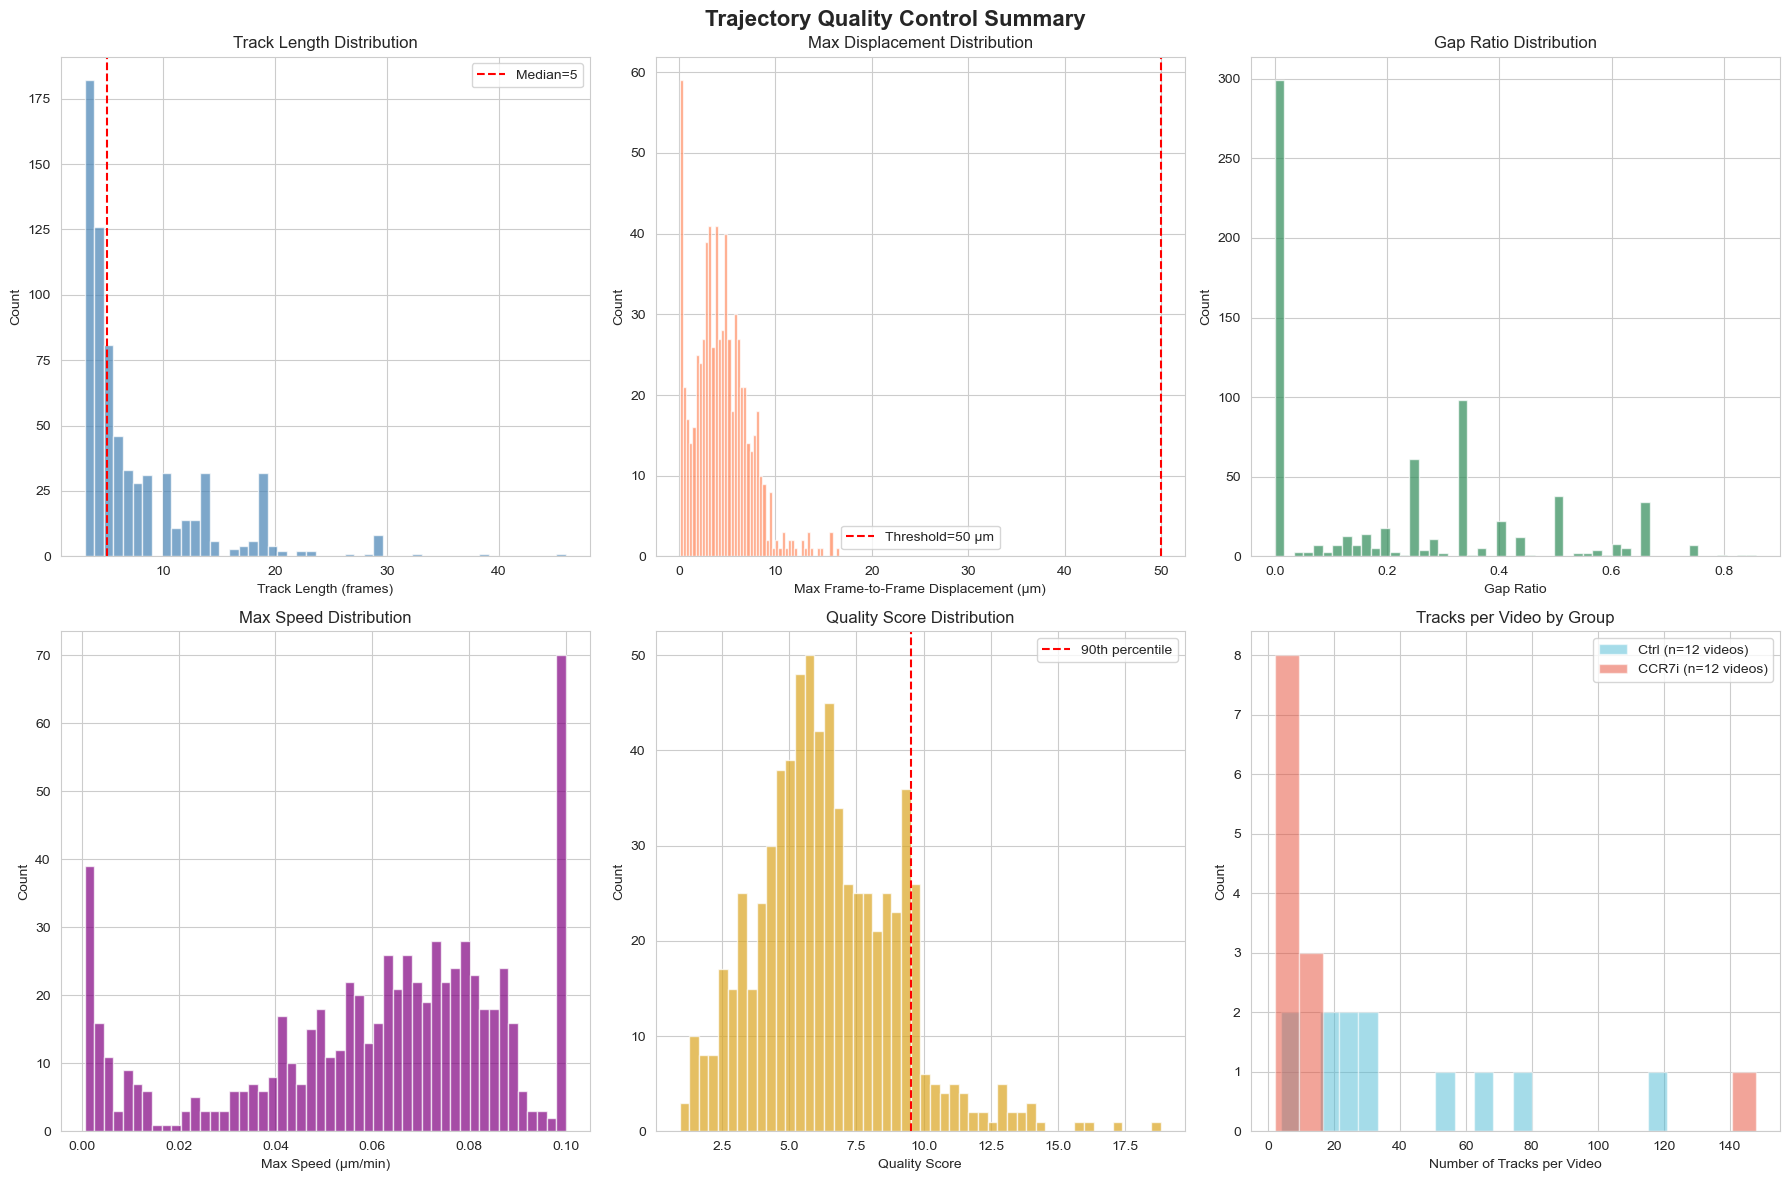


轨迹过滤
过滤前轨迹数: 181
排除原因:
  跳跃过大 (> 30 μm): 0
  Gap过大 (> 3 帧): 0
  轨迹过短 (< 3 帧): 0
  质量差得分过高 (> 90%): 71
过滤后轨迹数: 180
保留比例: 99.4%
趋近时刻: 2046 行 (45.6%)
方案校验通过：Ctrl 12 视频, CCR7i 11 视频 均在数据集中

使用匹配方案
每组视频数: 12
方案来源: match_info_20260624_105543.csv
Ctrl 视频: 12
CCR7i 视频: 11

匹配后细胞数:
  CD4_Tn Ctrl: 102 个细胞
  CD4_Tn CCR7i: 29 个细胞
  CD8_Tn Ctrl: 72 个细胞
  CD8_Tn CCR7i: 64 个细胞

混合效应模型分析（Ctrl为reference）

--- CD4_Tn ---
总细胞数: 131
视频数: 19
  Ctrl 组均值: 0.061150 μm/min (n=102 cells)
  CCR7i 组均值: 0.007874 μm/min (n=29 cells)


D:\Softwares\Anaconda\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
D:\Softwares\Anaconda\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
D:\Softwares\Anaconda\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
D:\Softwares\Anaconda\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
D:\Softwares\Anaconda\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


模型拟合结果:
                     Mixed Linear Model Regression Results
Model:                  MixedLM       Dependent Variable:       mean_v_approach
No. Observations:       131           Method:                   REML           
No. Groups:             19            Scale:                    0.0008         
Min. group size:        1             Log-Likelihood:           268.0065       
Max. group size:        25            Converged:                No             
Mean group size:        6.9                                                    
-------------------------------------------------------------------------------
                                     Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------------
Intercept                             0.062    0.005 13.607 0.000  0.053  0.071
C(group, Treatment('Ctrl'))[T.CCR7i] -0.054    0.008 -6.921 0.000 -0.070 -0.039
Group Var                             0.000    0.002

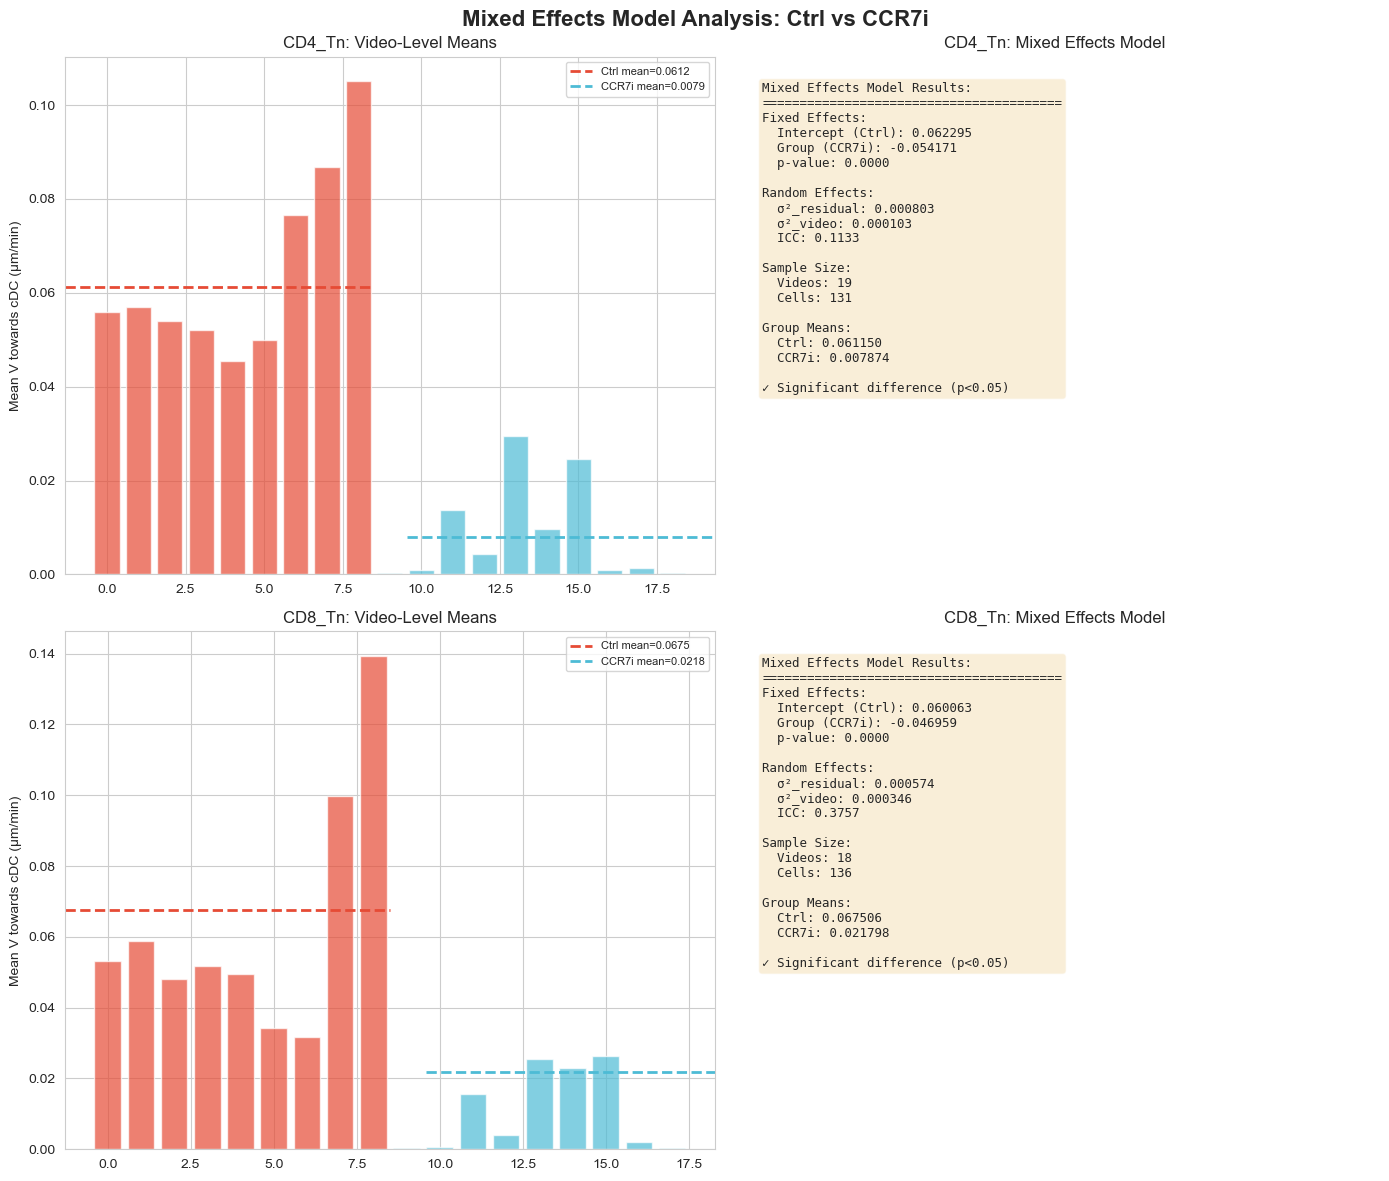

保存: CD4_Tn_violin_matched_qc.png


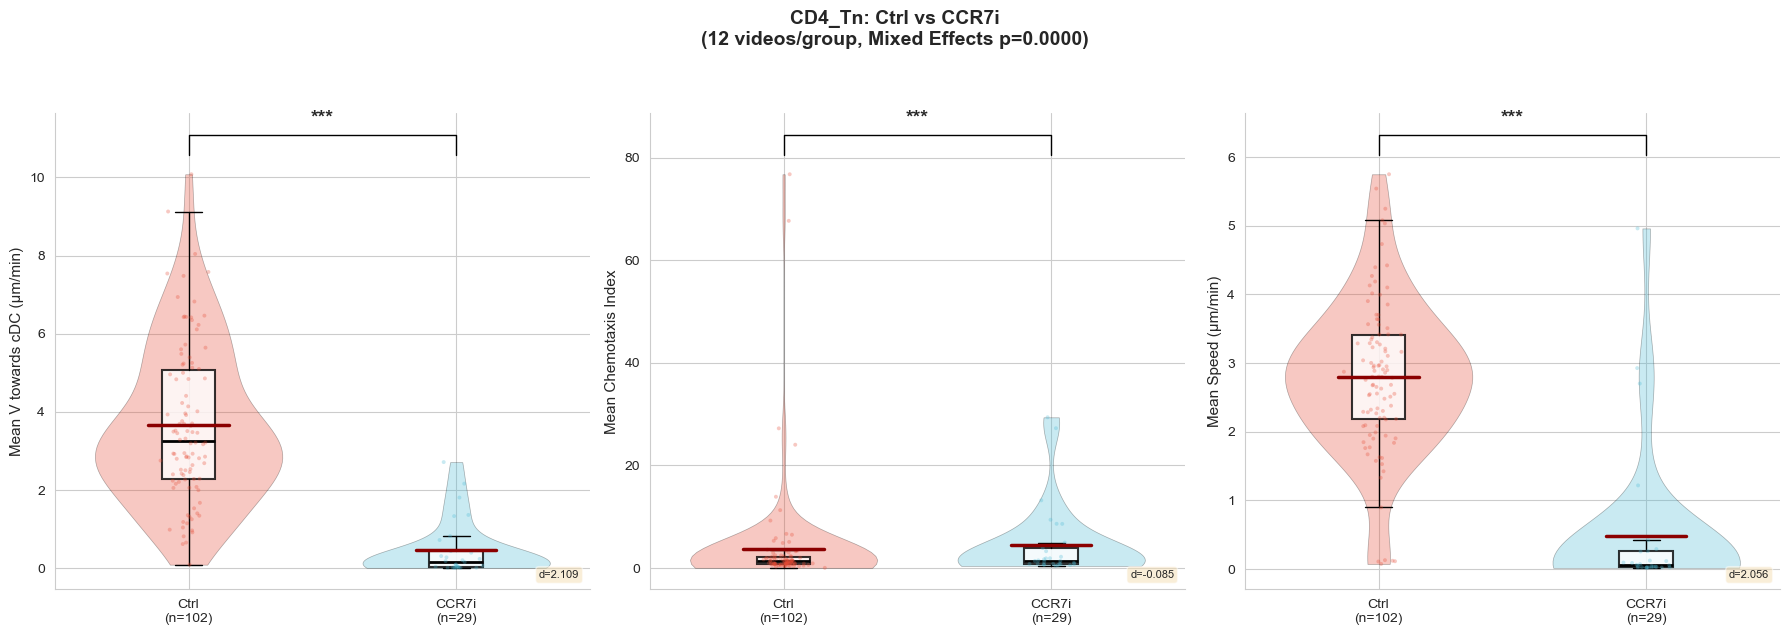

保存: CD8_Tn_violin_matched_qc.png


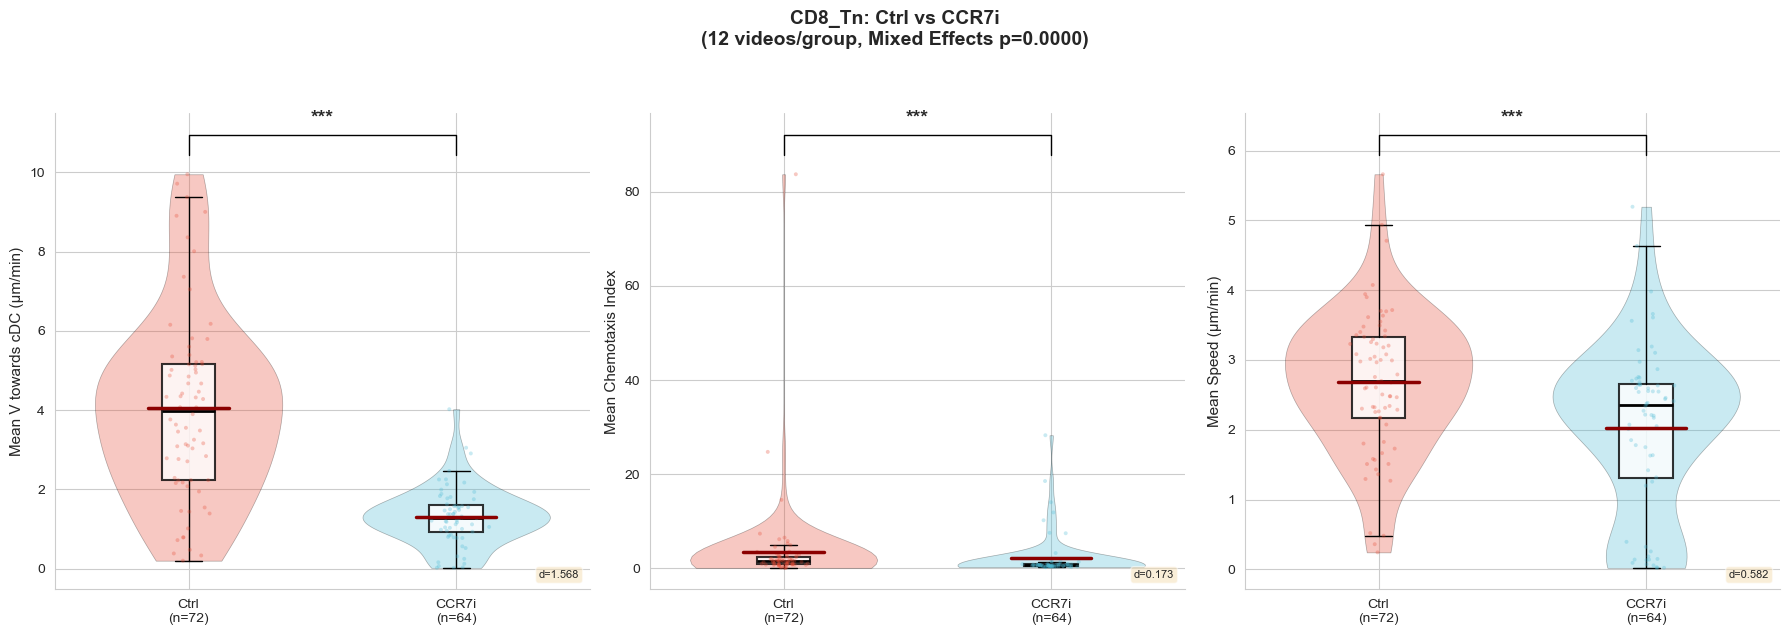

保存: combined_matched_qc.png


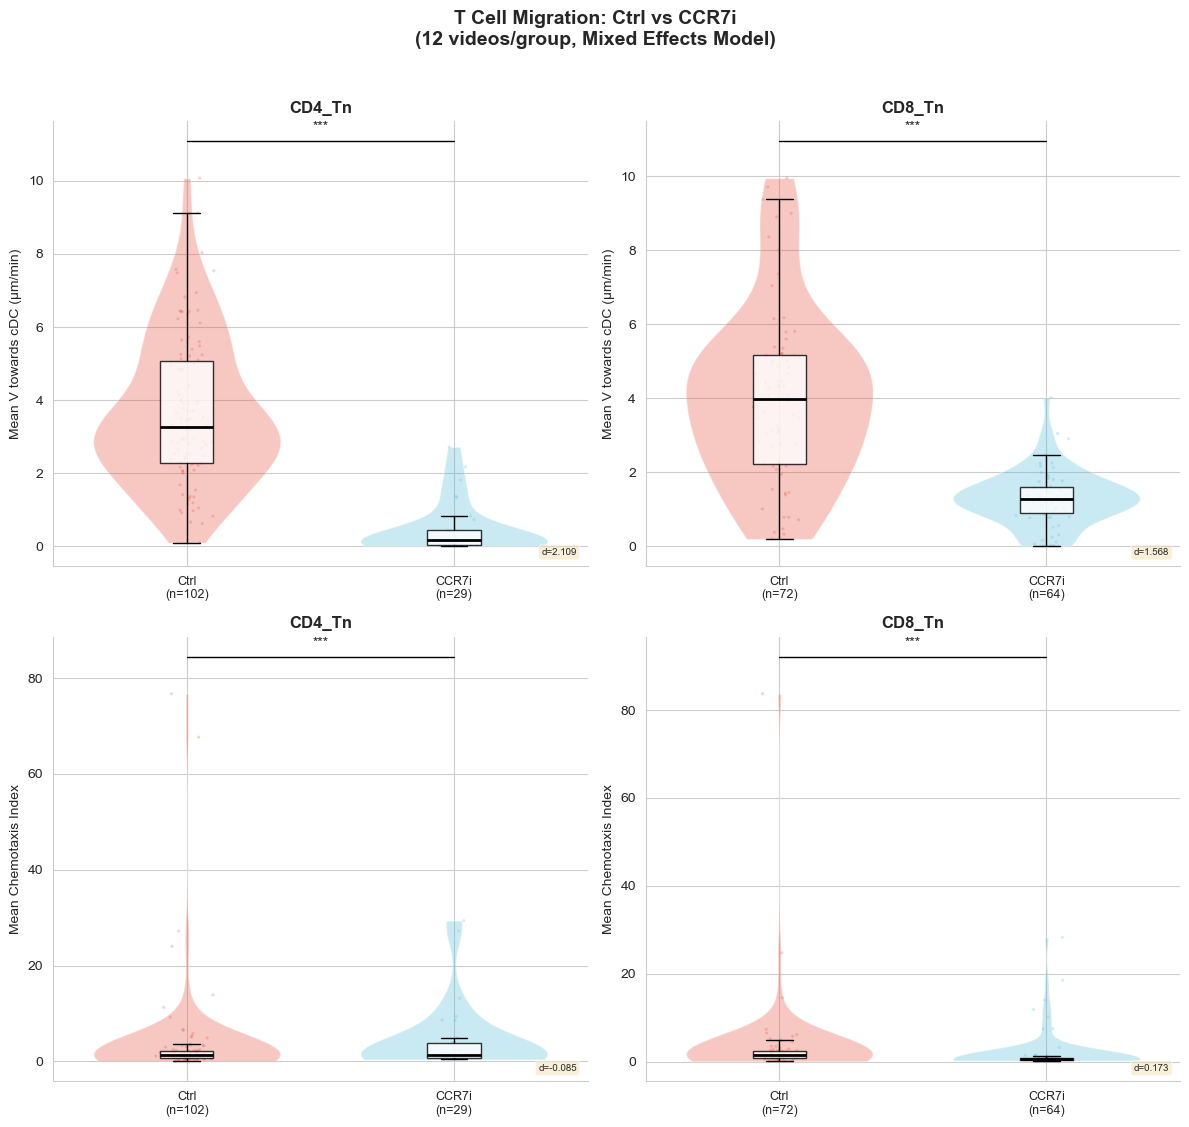


所有结果已导出: 20260917_144352


D:\Softwares\Anaconda\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
D:\Softwares\Anaconda\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(



统计 source data 已导出: statistics_source_data_20260917_144353.csv
Cell_type                 Metric  Ctrl_N  Ctrl_Mean  Ctrl_SEM  Ctrl_Median   Ctrl_SD  CCR7i_N  CCR7i_Mean  CCR7i_SEM  CCR7i_Median  CCR7i_SD  MannWhitney_U  MannWhitney_p   Ttest_t      Ttest_p  Cohens_d  MixedEffects_p  N_Videos_Ctrl  N_Videos_CCR7i  MannWhitney_p_FDR  Ttest_p_FDR Significance_FDR
   CD4_Tn V towards cDC (μm/min)     102   3.669022  0.199958     3.251959  2.019473       29    0.472461   0.133363      0.159282  0.718184         2841.0   4.425637e-14  8.355251 8.930515e-14  2.109113    4.475928e-12              9              10       2.655382e-13 1.786103e-13              ***
   CD4_Tn       Chemotaxis Index     102   3.731864  1.041789     1.291188 10.521557       29    4.499451   1.363312      1.394526  7.341660         1341.0   4.459005e-01 -0.367749 7.136632e-01 -0.084610             NaN              9              10       4.459005e-01 7.136632e-01               ns
   CD4_Tn         Speed (μm/min)    

In [15]:
# =============================================================================
# 主函数
# =============================================================================

def main():
    print("="*70)
    print("完整分析：轨迹QC + 样本匹配 + 混合效应模型")
    print("="*70)

    # 1. 加载数据
    df_frame = load_frame_data()

    # 2. 轨迹质量控制
    df_quality = evaluate_track_quality(df_frame)
    plot_quality_control_summary(df_quality, OUTPUT_DIR)

    df_frame_filtered, good_tracks, video_qc_stats = filter_tracks_by_quality(df_frame, df_quality)

    # 3. 计算视频级别指标
    video_stats = calculate_video_level_metrics(df_frame_filtered)

    # 4. 使用样本方案
    best_match = SAMPLE_MATCH_PLAN
    verify_sample_match_plan(best_match, df_frame_filtered)

    print(f"\n{'='*70}")
    print("使用匹配方案")
    print(f"{'='*70}")
    print(f"每组视频数: {best_match['n_videos_per_group']}")
    print(f"方案来源: {os.path.basename(SAMPLE_MATCH_FILE)}")
    print(f"Ctrl 视频: {len(best_match['ctrl_videos'])}")
    print(f"CCR7i 视频: {len(best_match['ccri_videos'])}")

    # 5. 获取细胞数据
    kept_videos = best_match['ctrl_videos'] + best_match['ccri_videos']
    cell_metrics = get_cell_metrics_for_videos(df_frame_filtered, kept_videos)

    print(f"\n匹配后细胞数:")
    for ct in ['CD4_Tn', 'CD8_Tn']:
        for grp in ['Ctrl', 'CCR7i']:
            n = len(cell_metrics[(cell_metrics['cell_type']==ct) & (cell_metrics['group']==grp)])
            print(f"  {ct} {grp}: {n} 个细胞")

    # 6. 混合效应模型
    mixed_results = run_mixed_effects_model_fixed(cell_metrics, OUTPUT_DIR)
    plot_mixed_effects_results(cell_metrics, mixed_results, OUTPUT_DIR)

    # 7. 细胞级别绘图
    plot_cell_level_violin(cell_metrics, best_match, mixed_results, OUTPUT_DIR)
    plot_combined_figure(cell_metrics, best_match, mixed_results, OUTPUT_DIR)

    # 8. 导出
    export_all_results(cell_metrics, best_match, mixed_results, df_quality, OUTPUT_DIR)

    # 9. 统计结果 source data（含 LMM/Wilcoxon/BH 校正/效应量）
    compute_statistics_source_data(cell_metrics, OUTPUT_DIR)


if __name__ == "__main__":
    main()